In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter
from scipy.stats import binom, norm

# Mini-Project 3 (Part 1): Simplified CDO analysis

FRE 6103 Valuation for Financial Engineering (NYU Tandon) | Raj Pawar (rsp9234) and Michael Brick (mb11311)

Ten 5-year speculative grade bonds sit in a CDO. We simulate 1000 cases of correlated default
times from a fixed set of random numbers, turn each case into quarterly cash flows for the 10
bonds with the BIS debt model, and push the pooled cash through the waterfall
(Class A, then Class B, then the bank's equity).

To look at a single case, change `CASE` in section 7. Valuation is Part 2 and is not done here.

## 1. Inputs

All dollar amounts are in $ millions. The YTM and the risk-free rate are listed because they are
given, but they are only needed for the valuation in Part 2.

In [2]:
N_CASES = 1000
SEED = 6103                   # for the fixed random numbers

base = {
    "n_bonds": 10,
    "years": 5,
    "freq": 4,                # payments per year
    "face": 10.0,             # $MM per bond
    "coupon": 0.06,           # annual, paid quarterly
    "pd": 0.04,               # annual default probability (pi)
    "lgd": 0.6,               # loss given default (lambda)
    "rho": 0.2,               # "correlation" between any two bonds' default dates
    "a_notional": 20.0,       # Class A
    "a_coupon": 0.02,
    "b_notional": 10.0,       # Class B
    "b_coupon": 0.04,
}

N_BONDS = base["n_bonds"]
FREQ = base["freq"]
N_PERIODS = base["years"] * base["freq"]      # 20 quarters

MARKET_YTM = 0.09             # Part 2
RISK_FREE = 0.01              # Part 2

quarters = np.arange(1, N_PERIODS + 1)

## 2. The BIS debt model for one bond

From Lecture 5: the bond is split into a non-defaultable part, (1 - LGD) of every promised
payment, which is always paid, and a defaultable part, LGD of every promised payment, which
stops in the period of default. So a bond that defaults in period k pays the full promised
amount in periods 1..k-1 and (1 - LGD) x promised from period k through maturity. Principal
is treated the same way as the coupons.

Before using it on the CDO, the function is checked against the example on the lecture slide
(face 1000, 5.5% annual coupon, LGD 60%, pi 3%, r 4%), which should give a value of 984.73.

In [3]:
def promised_cash_flows(face, coupon, n_periods, freq):
    """Coupon every period and the face value with the last coupon."""
    cf = np.full(n_periods, face * coupon / freq)
    cf[-1] += face
    return cf


def bis_cash_flows(promised, default_period, lgd):
    """Cash flows of bonds given the period in which each one defaults.

    BIS model: (1 - lgd) of every promised payment is always paid and the other
    lgd stops in the period of default. default_period can be any shape; the
    result has one more axis for the periods. A default_period beyond the last
    period means the bond never defaults.
    """
    periods = np.arange(1, len(promised) + 1)
    default_period = np.asarray(default_period)[..., None]
    paid_share = np.where(periods >= default_period, 1.0 - lgd, 1.0)
    return promised * paid_share


def bis_expected_value(promised, pd_per_period, lgd, rate_per_period):
    """Probability-weighted present value over every possible default period.

    This is the table on the BIS slide in Lecture 5. Returns (rows, value) where
    each row is (default period, probability, PV) and period None means no default.
    """
    n = len(promised)
    discount = (1.0 + rate_per_period) ** -np.arange(1, n + 1)
    rows = []
    for k in range(1, n + 2):
        survived = k > n
        prob = (1.0 - pd_per_period) ** n if survived else pd_per_period * (1.0 - pd_per_period) ** (k - 1)
        pv = float((bis_cash_flows(promised, k, lgd) * discount).sum())
        rows.append((None if survived else k, prob, pv))
    value = sum(prob * pv for _, prob, pv in rows)
    return rows, value


# Check against the BIS slide in Lecture 5 (annual payments).
slide_promised = promised_cash_flows(1000, 0.055, 5, 1)
rows, value = bis_expected_value(slide_promised, 0.03, 0.60, 0.04)
for year, prob, pv in rows:
    print(f"default year {year if year else 'none'}:  prob {prob:6.2%}   PV {pv:8.2f}")
print(f"Expected PV = {value:.2f}  (slide: 984.73)")

default year 1:  prob  3.00%   PV   426.71
default year 2:  prob  2.91%   PV   458.44
default year 3:  prob  2.82%   PV   488.95
default year 4:  prob  2.74%   PV   518.29
default year 5:  prob  2.66%   PV   546.50
default year none:  prob 85.87%   PV  1066.78
Expected PV = 984.73  (slide: 984.73)


## 3. Fixed random numbers

1000 cases x 10 bonds of independent standard normals. They were drawn once with a fixed seed and
stored in `fixed_random_numbers.csv`. The notebook reads that file, so every run (and Part 2) uses
exactly the same numbers. If the file is missing it is created again from the same seed. Cases are
numbered 1 to 1000.

In [4]:
def load_fixed_normals(path, n_cases, n_bonds, seed):
    """Read the fixed random numbers, creating the file from the seed if it is missing.

    Returns (table, source). The values are always the ones stored in the file,
    so every run uses exactly the same numbers. Cases are numbered from 1.
    """
    path = Path(path)
    if path.exists():
        source = "read from file"
    else:
        rng = np.random.default_rng(seed)
        columns = [f"Bond {i}" for i in range(1, n_bonds + 1)]
        index = pd.RangeIndex(1, n_cases + 1, name="case")
        draws = pd.DataFrame(rng.standard_normal((n_cases, n_bonds)), columns=columns, index=index)
        path.parent.mkdir(parents=True, exist_ok=True)
        draws.to_csv(path, float_format="%.10f")
        source = f"generated with seed {seed}"
    table = pd.read_csv(path, index_col="case")
    if table.shape != (n_cases, n_bonds):
        raise ValueError(f"{path} has shape {table.shape}, expected {(n_cases, n_bonds)}")
    if not np.isfinite(table.values).all():
        raise ValueError(f"{path} contains values that are not finite numbers")
    return table, source


candidates = [Path("fixed_random_numbers.csv"), Path("../data/fixed_random_numbers.csv")]
random_file = next((f for f in candidates if f.exists()), candidates[0])

z_table, source = load_fixed_normals(random_file, N_CASES, N_BONDS, SEED)
Z_raw = z_table.values
bond_names = list(z_table.columns)
print(f"Independent normals: {Z_raw.shape[0]} cases x {Z_raw.shape[1]} bonds ({source})")
z_table.head()

Independent normals: 1000 cases x 10 bonds (read from file)


,Bond 1,Bond 2,Bond 3,Bond 4,Bond 5,Bond 6,Bond 7,Bond 8,Bond 9,Bond 10
case,,,,,,,,,,
1,-0.389205,1.157821,0.094404,0.347190,1.110191,0.658477,1.046767,-0.473348,-0.652418,-0.111504
2,-0.743672,1.212835,-0.521107,0.865185,0.493481,0.540806,0.114611,0.804709,0.653957,0.219143
3,1.092946,-1.038571,0.389650,-0.491659,-0.703602,-0.180830,-0.790995,0.122441,-0.219314,-0.470948
4,-0.434196,1.915500,-0.939071,-0.405338,-0.050326,1.311731,-0.881236,-1.606150,-0.910297,-1.065262
5,-1.859987,0.750618,0.222459,-0.783419,-1.526318,-0.785312,-0.834635,-0.079704,-0.832377,0.285846


### Moment matching

1000 draws never have exactly the moments they are supposed to have. Each bond's numbers have a mean
a little away from 0 and a variance a little away from 1, and two bonds' numbers are slightly
correlated just by chance. As shown in class, we take this out before the numbers are used:

1. subtract each column's mean (de-mean),
2. compute the covariance matrix of the draws and its Cholesky factor L,
3. multiply the de-meaned draws by the inverse of L.

The result `Z` has column means of exactly 0, variances of exactly 1 and no correlation between
columns, and it is what the model uses from here on. The numbers are still fixed: the same file
always gives the same `Z`.

In [5]:
def moment_match(Z):
    """De-mean the draws and rescale them so the sample has exactly the moments of independent standard normals.

    As shown in class: subtract each column's mean, take the population covariance of the draws and
    multiply the de-meaned draws by the inverse of its Cholesky factor. Afterwards every bond's
    numbers have mean 0 and variance 1 across the cases, and no two bonds' numbers are correlated.
    """
    Z = np.asarray(Z, dtype=float)
    if Z.ndim != 2 or Z.shape[0] <= Z.shape[1]:
        raise ValueError(f"moment matching needs a cases x bonds table with more cases than bonds, got shape {Z.shape}")
    demeaned = Z - Z.mean(axis=0)
    covariance = demeaned.T @ demeaned / len(Z)
    chol = np.linalg.cholesky(covariance)
    return np.linalg.solve(chol, demeaned.T).T      # same as demeaned @ inverse(chol).T


Z = moment_match(Z_raw)


def largest_correlation(A):
    corr = np.corrcoef(A, rowvar=False)
    return np.abs(corr[~np.eye(A.shape[1], dtype=bool)]).max()


check_moments = pd.DataFrame({
    "largest |column mean|": [np.abs(Z_raw.mean(axis=0)).max(), np.abs(Z.mean(axis=0)).max()],
    "smallest variance": [Z_raw.var(axis=0).min(), Z.var(axis=0).min()],
    "largest variance": [Z_raw.var(axis=0).max(), Z.var(axis=0).max()],
    "largest |correlation| between two bonds": [largest_correlation(Z_raw), largest_correlation(Z)],
}, index=["as drawn", "moment matched"])
check_moments.round(4).abs()

,largest |column mean|,smallest variance,largest variance,largest |correlation| between two bonds
as drawn,0.0672,0.9579,1.0388,0.0875
moment matched,0.0000,1.0000,1.0000,0.0000


## 4. Correlated default times

Steps for every case:

1. Correlate the 10 moment-matched normals with the Cholesky factor of the 10 x 10 correlation
   matrix (1 on the diagonal, 0.20 everywhere else).
2. Convert each correlated normal to a uniform with the normal CDF, u = N(x).
3. Convert the uniform to a default time in years with the formula from class,
   t = ln(1 - u) / ln(1 - pi).
4. The bond defaults in quarter ceil(4t). If that is past quarter 20 the bond survives to maturity
   (stored as quarter 21).

The correlation is applied to the normals (a Gaussian copula). Because the numbers were moment
matched, the correlated normals have a correlation of exactly 0.20 across the 1000 cases. The
correlation of the default times themselves comes out a little below 0.20. Each bond on its own still has the geometric
default time with pi = 4% per year, so P(default by quarter k) = 1 - 0.96^(k/4).

In [6]:
def correlation_matrix(n, rho):
    """n x n matrix with 1 on the diagonal and rho everywhere else."""
    corr = np.full((n, n), float(rho))
    np.fill_diagonal(corr, 1.0)
    return corr


def correlate(Z, rho):
    """Turn independent normals (cases x bonds) into normals with pairwise correlation rho."""
    chol = np.linalg.cholesky(correlation_matrix(Z.shape[1], rho))
    return Z @ chol.T


def default_times(Z, pd_annual, rho):
    """Default time in years for every case and bond.

    u = N(x) for the correlated normals x, then t = ln(1 - u) / ln(1 - pi) as in
    Lecture 5. With pi = 0 nothing ever defaults.
    """
    if pd_annual == 0:
        return np.full(Z.shape, np.inf)
    U = norm.cdf(correlate(Z, rho))
    with np.errstate(divide="ignore"):
        return np.log(1.0 - U) / np.log(1.0 - pd_annual)


def default_period(T, freq, n_periods):
    """Period in which default happens (1, 2, ...). n_periods + 1 means the bond survives."""
    period = np.ceil(np.minimum(np.asarray(T, dtype=float) * freq, n_periods + 1))
    return np.maximum(period, 1).astype(int)


def average_pairwise_correlation(A):
    """Mean of the off-diagonal sample correlations between the columns of A."""
    corr = np.corrcoef(np.asarray(A, dtype=float).T)
    return float(corr[~np.eye(corr.shape[0], dtype=bool)].mean())


X = correlate(Z, base["rho"])
T = default_times(Z, base["pd"], base["rho"])
Q = default_period(T, FREQ, N_PERIODS)
defaulted = Q <= N_PERIODS
n_defaults = defaulted.sum(axis=1)

p_default = 1 - (1 - base["pd"]) ** base["years"]
print(f"Average pairwise correlation of the correlated normals:  {average_pairwise_correlation(X):.3f}  (target {base['rho']:.2f})")
print(f"Average pairwise correlation of the default times:       {average_pairwise_correlation(T):.3f}")
print(f"Average pairwise correlation of the 5-year default flag: {average_pairwise_correlation(defaulted):.3f}")
print()
print(f"Share of bonds defaulting within 5 years: {defaulted.mean():.2%}  (theory 1 - 0.96^5 = {p_default:.2%})")
print(f"Average number of defaults per case:      {n_defaults.mean():.3f}  (theory {N_BONDS * p_default:.3f})")

Average pairwise correlation of the correlated normals:  0.200  (target 0.20)
Average pairwise correlation of the default times:       0.175
Average pairwise correlation of the 5-year default flag: 0.104

Share of bonds defaulting within 5 years: 18.21%  (theory 1 - 0.96^5 = 18.46%)
Average number of defaults per case:      1.821  (theory 1.846)


## 5. Collateral cash flows (Task 1)

Each bond promises 0.15 per quarter and 10.15 in quarter 20. The BIS function turns the default
quarters into cash flows for every case, bond and quarter, and the pool is the sum over the 10
bonds. The simulated average pool cash flow is compared with the exact expected value,
promised x [(1 - LGD) + LGD x 0.96^(k/4)].

In [7]:
def expected_pool_cash_flows(p):
    """Exact expected pool cash flow per period: promised x [(1 - LGD) + LGD x (1 - pi)^(k / freq)]."""
    n_periods = p["years"] * p["freq"]
    promised = p["n_bonds"] * promised_cash_flows(p["face"], p["coupon"], n_periods, p["freq"])
    survival = (1.0 - p["pd"]) ** (np.arange(1, n_periods + 1) / p["freq"])
    return promised * ((1.0 - p["lgd"]) + p["lgd"] * survival)


bond_promised = promised_cash_flows(base["face"], base["coupon"], N_PERIODS, FREQ)
pool_promised = N_BONDS * bond_promised

bond_cf = bis_cash_flows(bond_promised, Q, base["lgd"])      # (1000, 10, 20)
pool_cf = bond_cf.sum(axis=1)                                # (1000, 20)

pool_expected = expected_pool_cash_flows(base)
check = pd.DataFrame({
    "promised": pool_promised,
    "expected (exact)": pool_expected,
    "simulated mean": pool_cf.mean(axis=0),
    "simulated min": pool_cf.min(axis=0),
    "simulated max": pool_cf.max(axis=0),
}, index=pd.Index(quarters, name="quarter"))
check["sim / exact - 1 (%)"] = (check["simulated mean"] / check["expected (exact)"] - 1) * 100
check.round(4)

,promised,expected (exact),simulated mean,simulated min,simulated max,sim / exact - 1 (%)
quarter,,,,,,
1,1.5,1.4909,1.4909,1.32,1.5,0.0032
2,1.5,1.4818,1.4816,1.23,1.5,-0.0180
3,1.5,1.4729,1.4726,1.14,1.5,-0.0151
4,1.5,1.4640,1.4627,0.96,1.5,-0.0861
5,1.5,1.4552,1.4534,0.87,1.5,-0.1269
6,1.5,1.4465,1.4437,0.87,1.5,-0.1993
7,1.5,1.4379,1.4357,0.87,1.5,-0.1598
8,1.5,1.4294,1.4295,0.87,1.5,0.0063
9,1.5,1.4210,1.4204,0.87,1.5,-0.0470


## 6. Waterfall (Task 2)

Both classes are treated as bullet bonds that pay quarterly, like the collateral: Class A is owed
20 x 2% / 4 = 0.10 per quarter and 20.10 in quarter 20, Class B is owed 10 x 4% / 4 = 0.10 per
quarter and 10.10 in quarter 20.

Each quarter, on its own:

- Class A gets min(pool cash, amount due to A)
- Class B gets min(what is left, amount due to B)
- the bank's equity gets the rest

There are no carry-forwards, so a shortfall in one quarter is not made up later and excess cash
is not held back.

In [8]:
def waterfall(pool_cf, a_due, b_due):
    """Split pool cash flows (cases x periods) between Class A, Class B and equity.

    Each period stands alone: Class A is paid first up to what it is due, then
    Class B, and the residual goes to equity. No carry-forwards, so a shortfall
    is not made up later and nothing is held back.
    """
    a_paid = np.minimum(pool_cf, a_due)
    b_paid = np.minimum(pool_cf - a_paid, b_due)
    equity = pool_cf - a_paid - b_paid
    return {"A": a_paid, "B": b_paid, "Equity": equity}


a_due = promised_cash_flows(base["a_notional"], base["a_coupon"], N_PERIODS, FREQ)
b_due = promised_cash_flows(base["b_notional"], base["b_coupon"], N_PERIODS, FREQ)

paid = waterfall(pool_cf, a_due, b_due)
a_cf, b_cf, eq_cf = paid["A"], paid["B"], paid["Equity"]

assert np.allclose(a_cf + b_cf + eq_cf, pool_cf), "waterfall does not add up to the pool"
assert (eq_cf >= -1e-12).all()

a_short = (a_due - a_cf).sum(axis=1)
b_short = (b_due - b_cf).sum(axis=1)
print(f"Due to Class A: {a_due[0]:.2f} per quarter, {a_due[-1]:.2f} at maturity, {a_due.sum():.2f} in total")
print(f"Due to Class B: {b_due[0]:.2f} per quarter, {b_due[-1]:.2f} at maturity, {b_due.sum():.2f} in total")
print(f"Cases with any shortfall on Class A: {(a_short > 1e-9).sum()} of {N_CASES}")
print(f"Cases with any shortfall on Class B: {(b_short > 1e-9).sum()} of {N_CASES}")
print()
floor = pool_promised * (1 - base["lgd"])
print("Worst possible pool cash (all 10 bonds default in quarter 1): "
      f"{floor[0]:.2f} per quarter and {floor[-1]:.2f} at maturity")
print("Needed for A + B:                                             "
      f"{a_due[0] + b_due[0]:.2f} per quarter and {a_due[-1] + b_due[-1]:.2f} at maturity")

Due to Class A: 0.10 per quarter, 20.10 at maturity, 22.00 in total
Due to Class B: 0.10 per quarter, 10.10 at maturity, 12.00 in total
Cases with any shortfall on Class A: 0 of 1000
Cases with any shortfall on Class B: 0 of 1000

Worst possible pool cash (all 10 bonds default in quarter 1): 0.60 per quarter and 40.60 at maturity
Needed for A + B:                                             0.20 per quarter and 30.20 at maturity


With LGD at 60% the pool can never pay less than 40% of what it promised, which is 0.60 per
quarter and 40.60 at maturity. Classes A and B together need 0.20 per quarter and 30.20 at
maturity, so under the base inputs they are paid in full in every case, not only in the 1000
simulated ones. All of the default risk lands on the bank's equity. Section 9 shows which inputs
have to move before the classes are touched.

The steps above are also wrapped in one function, `simulate`, so the whole model can be rerun
with other inputs in section 9. It checks the inputs first and gives back the same arrays.

In [9]:
def validate_deal(p):
    """Raise ValueError if an input is outside the range the model can handle."""
    if not 0.0 <= p["pd"] < 1.0:
        raise ValueError(f"annual default probability must be in [0, 1), got {p['pd']}")
    if not 0.0 <= p["lgd"] <= 1.0:
        raise ValueError(f"LGD must be in [0, 1], got {p['lgd']}")
    if not 0.0 <= p["rho"] < 1.0:
        raise ValueError(f"correlation must be in [0, 1), got {p['rho']}")
    for key in ("face", "coupon", "a_notional", "a_coupon", "b_notional", "b_coupon"):
        if not p[key] >= 0:
            raise ValueError(f"{key} must be a number that is not negative, got {p[key]}")


def simulate(Z, p):
    """Run the whole model for the parameter set p on the independent normals Z (cases x bonds)."""
    validate_deal(p)
    if Z.ndim != 2 or Z.shape[1] != p["n_bonds"]:
        raise ValueError(f"random numbers must be a cases x {p['n_bonds']} table, got shape {Z.shape}")
    if not np.isfinite(Z).all():
        raise ValueError("random numbers contain values that are not finite")
    n_periods = p["years"] * p["freq"]
    bond_promised = promised_cash_flows(p["face"], p["coupon"], n_periods, p["freq"])
    T = default_times(Z, p["pd"], p["rho"])
    Q = default_period(T, p["freq"], n_periods)
    bond_cf = bis_cash_flows(bond_promised, Q, p["lgd"])
    pool_cf = bond_cf.sum(axis=1)
    a_due = promised_cash_flows(p["a_notional"], p["a_coupon"], n_periods, p["freq"])
    b_due = promised_cash_flows(p["b_notional"], p["b_coupon"], n_periods, p["freq"])
    paid = waterfall(pool_cf, a_due, b_due)
    return {
        "T": T,
        "Q": Q,
        "defaulted": Q <= n_periods,
        "bond_promised": bond_promised,
        "pool_promised": p["n_bonds"] * bond_promised,
        "bond_cf": bond_cf,
        "pool_cf": pool_cf,
        "a_due": a_due,
        "b_due": b_due,
        "a_cf": paid["A"],
        "b_cf": paid["B"],
        "eq_cf": paid["Equity"],
    }


r = simulate(Z, base)
assert np.array_equal(r["pool_cf"], pool_cf) and np.array_equal(r["eq_cf"], eq_cf)
print("simulate() reproduces the step-by-step cash flows")

simulate() reproduces the step-by-step cash flows


## 7. Look at one case

Set `CASE` to any number from 1 to 1000.

In [10]:
CASE = 5

assert 1 <= CASE <= N_CASES, "CASE must be between 1 and 1000"
i = CASE - 1
case_bonds = pd.DataFrame({
    "random normal (as drawn)": Z_raw[i],
    "moment matched": Z[i],
    "correlated normal": X[i],
    "uniform u": norm.cdf(X[i]),
    "default time (years)": T[i],
    "default quarter": np.where(defaulted[i], Q[i], 0),
}, index=bond_names)
case_bonds["status"] = np.where(defaulted[i], "defaults", "survives")
case_bonds["total cash received"] = bond_cf[i].sum(axis=1)
print(f"Case {CASE}: {n_defaults[i]} of {N_BONDS} bonds default within 5 years")
case_bonds.round(4)

Case 5: 6 of 10 bonds default within 5 years


,random normal (as drawn),moment matched,correlated normal,uniform u,default time (years),default quarter,status,total cash received
Bond 1,-1.8600,-1.8690,-1.8690,0.0308,0.7666,4,defaults,5.47
Bond 2,0.7506,0.7323,0.3437,0.6344,24.6520,0,survives,13.00
Bond 3,0.2225,0.1839,-0.0766,0.4695,15.5281,0,survives,13.00
Bond 4,-0.7834,-0.7215,-0.9188,0.1791,4.8349,20,defaults,6.91
Bond 5,-1.5263,-1.4418,-1.6829,0.0462,1.1587,5,defaults,5.56
Bond 6,-0.7853,-0.7497,-1.1739,0.1202,3.1375,13,defaults,6.28
Bond 7,-0.8346,-0.7342,-1.2265,0.1100,2.8547,12,defaults,6.19
Bond 8,-0.0797,-0.1008,-0.6945,0.2437,6.8416,0,survives,13.00
Bond 9,-0.8324,-0.9549,-1.4972,0.0672,1.7033,7,defaults,5.74
Bond 10,0.2858,0.2507,-0.4439,0.3286,9.7582,0,survives,13.00


In [11]:
case_cf = pd.DataFrame(bond_cf[i].T, columns=bond_names, index=pd.Index(quarters, name="quarter"))
case_cf["Pool"] = pool_cf[i]
case_cf["Class A"] = a_cf[i]
case_cf["Class B"] = b_cf[i]
case_cf["Equity"] = eq_cf[i]
case_cf.loc["Total"] = case_cf.sum()
case_cf.round(3)

,Bond 1,Bond 2,Bond 3,Bond 4,Bond 5,Bond 6,Bond 7,Bond 8,Bond 9,Bond 10,Pool,Class A,Class B,Equity
quarter,,,,,,,,,,,,,,
1,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,1.50,0.1,0.1,1.30
2,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,1.50,0.1,0.1,1.30
3,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,1.50,0.1,0.1,1.30
4,0.06,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,1.41,0.1,0.1,1.21
5,0.06,0.15,0.15,0.15,0.06,0.15,0.15,0.15,0.15,0.15,1.32,0.1,0.1,1.12
6,0.06,0.15,0.15,0.15,0.06,0.15,0.15,0.15,0.15,0.15,1.32,0.1,0.1,1.12
7,0.06,0.15,0.15,0.15,0.06,0.15,0.15,0.15,0.06,0.15,1.23,0.1,0.1,1.03
8,0.06,0.15,0.15,0.15,0.06,0.15,0.15,0.15,0.06,0.15,1.23,0.1,0.1,1.03
9,0.06,0.15,0.15,0.15,0.06,0.15,0.15,0.15,0.06,0.15,1.23,0.1,0.1,1.03


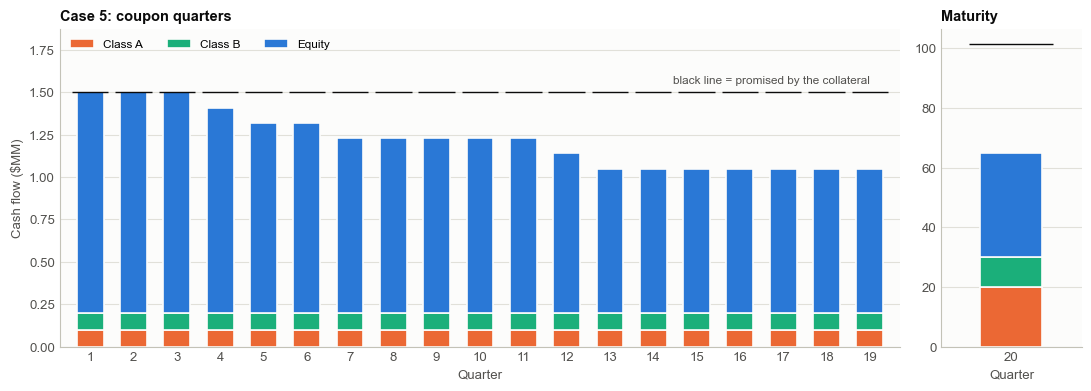

In [12]:
# One colour per entity in every chart.
COLORS = {'surface': '#fcfcfb',
 'ink': '#0b0b0b',
 'ink_secondary': '#52514e',
 'grid': '#e1e0d9',
 'axis': '#c3c2b7',
 'pool': '#52514e',
 'benchmark': '#898781',
 'equity': '#2a78d6',
 'class_a': '#eb6834',
 'class_b': '#1baf7a'}


def apply_chart_style():
    """Quiet chart defaults: thin marks, a hairline grid and no box around the plot."""
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 9.5,
        "figure.facecolor": "white",
        "axes.facecolor": COLORS["surface"],
        "axes.edgecolor": COLORS["axis"],
        "axes.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.grid.axis": "y",
        "axes.axisbelow": True,
        "grid.color": COLORS["grid"],
        "grid.linewidth": 0.8,
        "grid.linestyle": "-",
        "axes.labelcolor": COLORS["ink_secondary"],
        "axes.titlecolor": COLORS["ink"],
        "axes.titlesize": 10.5,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "xtick.color": COLORS["ink_secondary"],
        "ytick.color": COLORS["ink_secondary"],
        "xtick.major.size": 0,
        "ytick.major.size": 0,
        "legend.frameon": False,
        "legend.fontsize": 8.5,
        "lines.linewidth": 2.0,
        "lines.solid_capstyle": "round",
        "savefig.dpi": 160,
        "savefig.bbox": "tight",
    })


def plot_case(case, a_cf, b_cf, eq_cf, pool_promised):
    """Waterfall of one case: who receives the pool's cash in the coupon quarters and at maturity."""
    n = len(a_cf)
    series = [("Class A", a_cf, COLORS["class_a"]), ("Class B", b_cf, COLORS["class_b"]),
              ("Equity", eq_cf, COLORS["equity"])]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), gridspec_kw={"width_ratios": [6, 1]})
    for ax, start, stop in ((axes[0], 0, n - 1), (axes[1], n - 1, n)):
        x = np.arange(start + 1, stop + 1)
        bottom = np.zeros(stop - start)
        for name, cf, color in series:
            ax.bar(x, cf[start:stop], bottom=bottom, width=0.62, color=color, edgecolor=COLORS["surface"],
                   linewidth=1.2, label=name)
            bottom = bottom + cf[start:stop]
        ax.hlines(pool_promised[start:stop], x - 0.42, x + 0.42, color=COLORS["ink"], linewidth=1.0)
        ax.set_xticks(x)
        ax.set_xlim(x[0] - 0.7, x[-1] + 0.7)
    axes[0].annotate("black line = promised by the collateral", xy=(n - 1, pool_promised[0]), xytext=(0, 5),
                     textcoords="offset points", ha="right", va="bottom", fontsize=8.5,
                     color=COLORS["ink_secondary"])
    axes[0].set_ylim(0, pool_promised[0] * 1.25)
    axes[0].set_xlabel("Quarter")
    axes[0].set_ylabel("Cash flow ($MM)")
    axes[0].set_title(f"Case {case}: coupon quarters")
    axes[0].legend(loc="upper left", ncol=3)
    axes[1].set_xlabel("Quarter")
    axes[1].set_title("Maturity")
    fig.tight_layout()
    return fig


apply_chart_style()
plot_case(CASE, a_cf[i], b_cf[i], eq_cf[i], pool_promised)
plt.show()

## 8. Statistical analysis (Task 3)

Totals are the sum of the 20 quarterly cash flows, not discounted (discounting is Part 2).

The "no-default amount" is what the pool or the class would receive if no bond defaulted. The
standard error is the standard deviation divided by the square root of the number of cases. That
is the formula for independent cases. Moment matching ties the cases together, so the true sampling
error of a mean is smaller and this figure should be read as an upper bound. The check after the
table measures it by running the model on fresh sets of random numbers.

In [13]:
def describe(x, no_default):
    """Summary statistics of one total per case, next to what it would be with no defaults."""
    return {
        "no-default amount": no_default,
        "mean": x.mean(),
        "std dev": x.std(ddof=1),
        "std error": x.std(ddof=1) / np.sqrt(len(x)),      # of the mean if the cases were independent (an upper bound here)
        "min": x.min(),
        "5th pct": np.percentile(x, 5),
        "median": np.median(x),
        "95th pct": np.percentile(x, 95),
        "max": x.max(),
        "mean / no-default amount": x.mean() / no_default if no_default else np.nan,
    }


pool_total = pool_cf.sum(axis=1)
a_total = a_cf.sum(axis=1)
b_total = b_cf.sum(axis=1)
eq_total = eq_cf.sum(axis=1)
eq_promised = pool_promised.sum() - a_due.sum() - b_due.sum()

stats = pd.DataFrame({
    "Collateral pool": describe(pool_total, pool_promised.sum()),
    "Class A": describe(a_total, a_due.sum()),
    "Class B": describe(b_total, b_due.sum()),
    "Equity (bank)": describe(eq_total, eq_promised),
}).T
stats.round(3)

,no-default amount,mean,std dev,std error,min,5th pct,median,95th pct,max,mean / no-default amount
Collateral pool,130.0,117.283,12.032,0.38,64.48,94.686,122.29,130.0,130.0,0.902
Class A,22.0,22.000,0.000,0.00,22.00,22.000,22.00,22.0,22.0,1.000
Class B,12.0,12.000,0.000,0.00,12.00,12.000,12.00,12.0,12.0,1.000
Equity (bank),96.0,83.283,12.032,0.38,30.48,60.686,88.29,96.0,96.0,0.868


In [14]:
def sampling_error_check(base, n_cases, n_tables=2000, seed=6104):
    """How far the mean total pool cash moves from one set of random numbers to the next.

    Draws n_tables fresh sets, runs the model on each as drawn and after moment matching, and reports
    the standard deviation of the mean across sets. That is the real sampling error of the mean. The
    usual std dev / sqrt(n) formula only gives it when the cases are independent.
    """
    rng = np.random.default_rng(seed)
    as_drawn, matched, formula = [], [], []
    for _ in range(n_tables):
        Z = rng.standard_normal((n_cases, base["n_bonds"]))
        plain_total = simulate(Z, base)["pool_cf"].sum(axis=1)
        matched_total = simulate(moment_match(Z), base)["pool_cf"].sum(axis=1)
        as_drawn.append(plain_total.mean())
        matched.append(matched_total.mean())
        formula.append(matched_total.std(ddof=1) / np.sqrt(n_cases))
    return {
        "n_tables": n_tables,
        "seed": seed,
        "exact_mean": float(expected_pool_cash_flows(base).sum()),
        "mean_as_drawn": float(np.mean(as_drawn)),
        "mean_matched": float(np.mean(matched)),
        "sd_of_mean_as_drawn": float(np.std(as_drawn, ddof=1)),
        "sd_of_mean_matched": float(np.std(matched, ddof=1)),
        "average_formula_std_error": float(np.mean(formula)),
    }


sampling = sampling_error_check(base, N_CASES, n_tables=300)
print(f"Mean total pool cash over {sampling['n_tables']} fresh sets of random numbers (exact value {sampling['exact_mean']:.2f})")
print(f"  as drawn:        {sampling['mean_as_drawn']:.2f} on average, varies by {sampling['sd_of_mean_as_drawn']:.3f} from set to set")
print(f"  moment matched:  {sampling['mean_matched']:.2f} on average, varies by {sampling['sd_of_mean_matched']:.3f} from set to set")
print(f"  std dev / sqrt(n) on a moment-matched set: {sampling['average_formula_std_error']:.3f}")

Mean total pool cash over 300 fresh sets of random numbers (exact value 117.12)
  as drawn:        117.12 on average, varies by 0.363 from set to set
  moment matched:  117.11 on average, varies by 0.146 from set to set
  std dev / sqrt(n) on a moment-matched set: 0.380


The number of defaults per case is compared with two benchmarks. The first is the exact
distribution under the model itself, worked out without random numbers: equal pairwise correlation
is the same as one common factor shared by all bonds, and given that factor the bonds default
independently. It shows how close 1000 cases come to the true distribution. The second is the
binomial that would apply if the bonds defaulted independently, which shows what the correlation does.

In [15]:
def exact_default_count_distribution(n_bonds, p_default, rho, steps=2000):
    """Exact distribution of the number of defaults under the model, with no random numbers.

    Equal pairwise correlation rho is the same as one common factor M shared by all bonds. Given M
    the bonds default independently with probability N((N^-1(p) - sqrt(rho) M) / sqrt(1 - rho)),
    so the answer is a binomial averaged over M. The average uses Simpson's rule on -9 to 9, which
    stays accurate at high correlation where the conditional probability is close to a step.
    """
    k = np.arange(n_bonds + 1)
    if rho == 0 or p_default in (0.0, 1.0):
        return binom.pmf(k, n_bonds, p_default)
    m = np.linspace(-9.0, 9.0, steps + 1)
    simpson = np.ones(steps + 1)
    simpson[1:-1:2] = 4.0
    simpson[2:-1:2] = 2.0
    weights = simpson * (m[1] - m[0]) / 3.0 * norm.pdf(m)
    conditional = norm.cdf((norm.ppf(p_default) - np.sqrt(rho) * m) / np.sqrt(1.0 - rho))
    return (binom.pmf(k[:, None], n_bonds, conditional[None, :]) * weights).sum(axis=1)


def default_count_table(n_defaults, pool_total, eq_total, n_bonds, p_default, rho):
    """Distribution of the number of defaults: simulated, exact under the model, and if independent."""
    k = np.arange(n_bonds + 1)
    counts = np.bincount(n_defaults, minlength=n_bonds + 1)
    return pd.DataFrame({
        "cases": counts,
        "simulated probability": counts / len(n_defaults),
        "exact with correlation": exact_default_count_distribution(n_bonds, p_default, rho),
        "if independent (binomial)": binom.pmf(k, n_bonds, p_default),
        "avg pool cash ($MM)": [pool_total[n_defaults == j].mean() if counts[j] else np.nan for j in k],
        "avg equity cash ($MM)": [eq_total[n_defaults == j].mean() if counts[j] else np.nan for j in k],
    }, index=pd.Index(k, name="defaults in 5 years"))


default_dist = default_count_table(n_defaults, pool_total, eq_total, N_BONDS, p_default, base["rho"])
default_dist.round(4)

,cases,simulated probability,exact with correlation,if independent (binomial),avg pool cash ($MM),avg equity cash ($MM)
defaults in 5 years,,,,,,
0,257,0.257,0.2470,0.1299,130.0000,96.0000
1,253,0.253,0.2588,0.2941,123.1313,89.1313
2,200,0.200,0.1988,0.2997,116.0857,82.0857
3,131,0.131,0.1328,0.1810,109.1337,75.1337
4,77,0.077,0.0805,0.0717,101.9126,67.9126
5,49,0.049,0.0446,0.0195,94.9655,60.9655
6,16,0.016,0.0225,0.0037,87.5369,53.5369
7,11,0.011,0.0100,0.0005,79.9409,45.9409
8,5,0.005,0.0038,0.0000,72.4960,38.4960


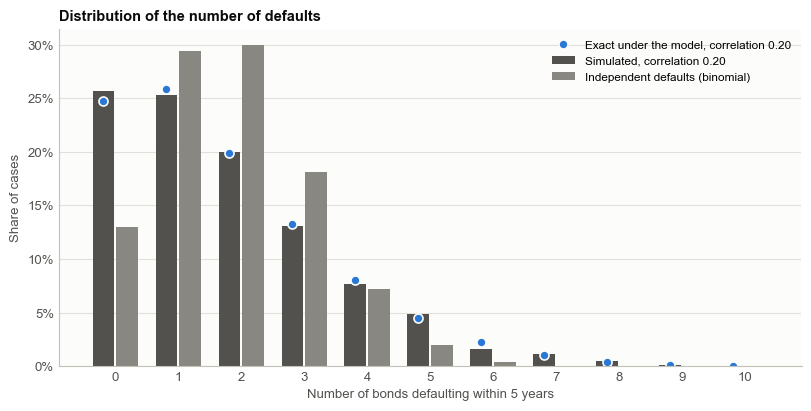

In [16]:
def plot_default_count(table, rho):
    """Number of defaults per case: simulated, exact under the model, and if defaults were independent."""
    fig, ax = plt.subplots(figsize=(8.2, 4.2))
    k = table.index.values
    ax.bar(k - 0.19, table["simulated probability"], width=0.34, color=COLORS["pool"],
           label=f"Simulated, correlation {rho:.2f}")
    ax.bar(k + 0.19, table["if independent (binomial)"], width=0.34, color=COLORS["benchmark"],
           label="Independent defaults (binomial)")
    ax.plot(k - 0.19, table["exact with correlation"], linestyle="none", marker="o", markersize=6.5,
            color=COLORS["equity"], markeredgecolor=COLORS["surface"], markeredgewidth=1.2,
            label=f"Exact under the model, correlation {rho:.2f}")
    ax.set_xticks(k)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    ax.set_xlabel("Number of bonds defaulting within 5 years")
    ax.set_ylabel("Share of cases")
    ax.set_title("Distribution of the number of defaults")
    ax.legend()
    fig.tight_layout()
    return fig


plot_default_count(default_dist, base["rho"])
plt.show()

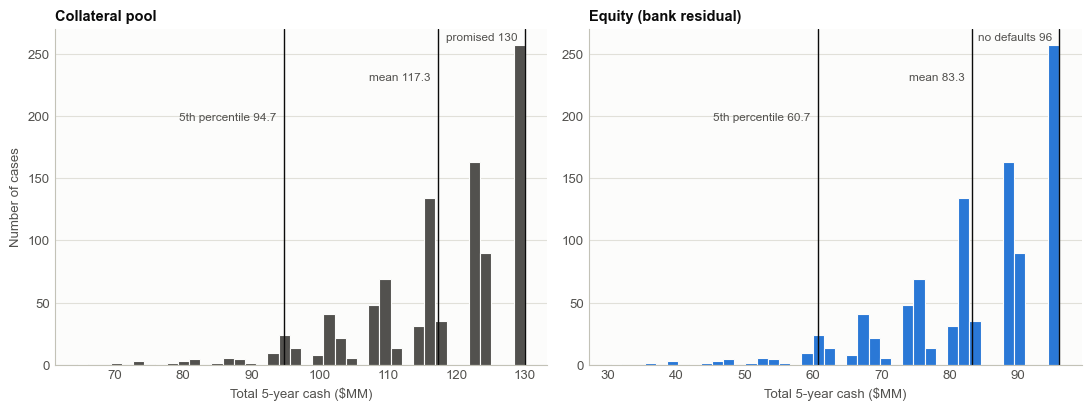

In [17]:
def reference_line(ax, x, text, height):
    """Vertical hairline with its label written beside it, so it needs no legend entry."""
    ax.axvline(x, color=COLORS["ink"], linewidth=1.0)
    ax.annotate(text, xy=(x, height), xycoords=("data", "axes fraction"), xytext=(-5, 0),
                textcoords="offset points", ha="right", va="top", fontsize=8.5, color=COLORS["ink_secondary"])


def plot_total_cash(pool_total, eq_total, pool_promised, eq_promised):
    """Distribution of total 5-year cash: the collateral pool (left) and the bank's equity (right)."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    panels = [
        (axes[0], pool_total, pool_promised, COLORS["pool"], "Collateral pool", "promised"),
        (axes[1], eq_total, eq_promised, COLORS["equity"], "Equity (bank residual)", "no defaults"),
    ]
    for ax, x, top, color, title, top_label in panels:
        ax.hist(x, bins=40, color=color, edgecolor=COLORS["surface"], linewidth=0.8)
        reference_line(ax, top, f"{top_label} {top:.0f}", 0.99)
        reference_line(ax, x.mean(), f"mean {x.mean():.1f}", 0.87)
        reference_line(ax, np.percentile(x, 5), f"5th percentile {np.percentile(x, 5):.1f}", 0.75)
        ax.set_title(title)
        ax.set_xlabel("Total 5-year cash ($MM)")
    axes[0].set_ylabel("Number of cases")
    fig.tight_layout()
    return fig


plot_total_cash(pool_total, eq_total, pool_promised.sum(), eq_promised)
plt.show()

In [18]:
def quarterly_table(r, pool_expected):
    """Per-period cash flow statistics across the cases for the pool and each class."""
    quarters = np.arange(1, r["pool_cf"].shape[1] + 1)
    return pd.DataFrame({
        "pool promised": r["pool_promised"],
        "pool expected (exact)": pool_expected,
        "pool mean": r["pool_cf"].mean(axis=0),
        "pool 5th pct": np.percentile(r["pool_cf"], 5, axis=0),
        "pool 95th pct": np.percentile(r["pool_cf"], 95, axis=0),
        "Class A mean": r["a_cf"].mean(axis=0),
        "Class B mean": r["b_cf"].mean(axis=0),
        "equity mean": r["eq_cf"].mean(axis=0),
        "equity 5th pct": np.percentile(r["eq_cf"], 5, axis=0),
        "equity 95th pct": np.percentile(r["eq_cf"], 95, axis=0),
    }, index=pd.Index(quarters, name="quarter"))


quarterly = quarterly_table(r, pool_expected)
quarterly.round(3)

,pool promised,pool expected (exact),pool mean,pool 5th pct,pool 95th pct,Class A mean,Class B mean,equity mean,equity 5th pct,equity 95th pct
quarter,,,,,,,,,,
1,1.5,1.491,1.491,1.41,1.5,0.1,0.1,1.291,1.21,1.3
2,1.5,1.482,1.482,1.41,1.5,0.1,0.1,1.282,1.21,1.3
3,1.5,1.473,1.473,1.32,1.5,0.1,0.1,1.273,1.12,1.3
4,1.5,1.464,1.463,1.32,1.5,0.1,0.1,1.263,1.12,1.3
5,1.5,1.455,1.453,1.32,1.5,0.1,0.1,1.253,1.12,1.3
6,1.5,1.447,1.444,1.23,1.5,0.1,0.1,1.244,1.03,1.3
7,1.5,1.438,1.436,1.23,1.5,0.1,0.1,1.236,1.03,1.3
8,1.5,1.429,1.430,1.23,1.5,0.1,0.1,1.230,1.03,1.3
9,1.5,1.421,1.420,1.23,1.5,0.1,0.1,1.220,1.03,1.3


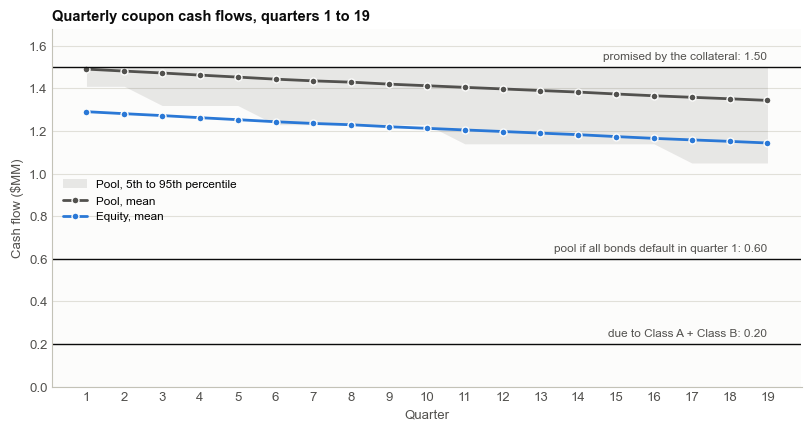

In [19]:
def plot_quarterly(quarterly, floor, classes_need):
    """Coupon quarters: what the pool pays (mean and 5th to 95th band) against what the classes need."""
    part = quarterly.iloc[:-1]
    q = part.index.values
    promised = part["pool promised"].iloc[0]
    marker = {"marker": "o", "markersize": 5, "markeredgecolor": COLORS["surface"], "markeredgewidth": 1.0}
    fig, ax = plt.subplots(figsize=(8.2, 4.4))
    ax.fill_between(q, part["pool 5th pct"], part["pool 95th pct"], color=COLORS["pool"], alpha=0.12, linewidth=0,
                    label="Pool, 5th to 95th percentile")
    ax.plot(q, part["pool mean"], color=COLORS["pool"], label="Pool, mean", **marker)
    ax.plot(q, part["equity mean"], color=COLORS["equity"], label="Equity, mean", **marker)
    levels = [
        (promised, f"promised by the collateral: {promised:.2f}"),
        (floor, f"pool if all bonds default in quarter 1: {floor:.2f}"),
        (classes_need, f"due to Class A + Class B: {classes_need:.2f}"),
    ]
    for level, text in levels:
        ax.axhline(level, color=COLORS["ink"], linewidth=1.0)
        ax.annotate(text, xy=(q[-1], level), xytext=(0, 4), textcoords="offset points", ha="right", va="bottom",
                    fontsize=8.5, color=COLORS["ink_secondary"])
    ax.set_xticks(q)
    ax.set_ylim(0, promised * 1.12)
    ax.set_xlabel("Quarter")
    ax.set_ylabel("Cash flow ($MM)")
    ax.set_title(f"Quarterly coupon cash flows, quarters 1 to {q[-1]}")
    ax.legend(loc="center left", bbox_to_anchor=(0.0, 0.52))
    fig.tight_layout()
    return fig


plot_quarterly(quarterly, floor[0], a_due[0] + b_due[0])
plt.show()

## 9. Sensitivities

Each input is changed one at a time and the whole model is rerun on the same 1000 x 10 fixed
random numbers, so the differences between rows come from the input and not from new draws.
A "shortfall" means the class received less than it was due in at least one quarter.

In [20]:
def summary_row(Z, p, tol=1e-09):
    """Key results for one parameter set (one row of a sensitivity table).

    A shortfall means the class received less than it was due in at least one period.
    """
    r = simulate(Z, p)
    n_defaults = r["defaulted"].sum(axis=1)
    pool = r["pool_cf"].sum(axis=1)
    equity = r["eq_cf"].sum(axis=1)
    a_short = (r["a_due"] - r["a_cf"]).sum(axis=1)
    b_short = (r["b_due"] - r["b_cf"]).sum(axis=1)
    b_due_total = r["b_due"].sum()
    return {
        "avg defaults": n_defaults.mean(),
        "P(no default)": (n_defaults == 0).mean(),
        "P(4+ defaults)": (n_defaults >= 4).mean(),
        "pool mean": pool.mean(),
        "pool 5th pct": np.percentile(pool, 5),
        "equity mean": equity.mean(),
        "equity std": equity.std(ddof=1),
        "equity 5th pct": np.percentile(equity, 5),
        "equity min": equity.min(),
        "P(A shortfall)": (a_short > tol).mean(),
        "P(B shortfall)": (b_short > tol).mean(),
        "B paid / due": r["b_cf"].sum(axis=1).mean() / b_due_total if b_due_total else np.nan,
    }


def sensitivity(Z, start, name, values):
    """Rerun the model on the same random numbers with one input changed at a time."""
    rows = {v: summary_row(Z, {**start, name: v}) for v in values}
    return pd.DataFrame(rows).T.rename_axis(name)


sens_pd = sensitivity(Z, base, "pd", (0.01, 0.02, 0.04, 0.06, 0.08, 0.12))
sens_pd.round(3)

,avg defaults,P(no default),P(4+ defaults),pool mean,pool 5th pct,equity mean,equity std,equity 5th pct,equity min,P(A shortfall),P(B shortfall),B paid / due
pd,,,,,,,,,,,,
0.01,0.514,0.652,0.011,126.444,115.480,92.444,6.005,81.480,46.98,0.0,0.0,1.0
0.02,0.960,0.472,0.046,123.303,107.586,89.303,8.559,73.586,44.01,0.0,0.0,1.0
0.04,1.821,0.257,0.159,117.283,94.686,83.283,12.032,60.686,30.48,0.0,0.0,1.0
0.06,2.644,0.136,0.300,111.512,84.957,77.512,14.250,50.957,28.86,0.0,0.0,1.0
0.08,3.426,0.076,0.446,106.019,78.550,72.019,15.604,44.550,21.87,0.0,0.0,1.0
0.12,4.730,0.019,0.685,96.714,67.612,62.714,16.557,33.612,20.34,0.0,0.0,1.0


In [21]:
sens_lgd = sensitivity(Z, base, "lgd", (0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0))
sens_lgd.round(3)

,avg defaults,P(no default),P(4+ defaults),pool mean,pool 5th pct,equity mean,equity std,equity 5th pct,equity min,P(A shortfall),P(B shortfall),B paid / due
lgd,,,,,,,,,,,,
0.4,1.821,0.257,0.159,121.522,106.457,87.522,8.022,72.457,52.320,0.000,0.000,1.000
0.5,1.821,0.257,0.159,119.403,100.571,85.403,10.027,66.571,41.400,0.000,0.000,1.000
0.6,1.821,0.257,0.159,117.283,94.686,83.283,12.032,60.686,30.480,0.000,0.000,1.000
0.7,1.821,0.257,0.159,115.164,88.800,81.164,14.038,54.800,19.560,0.000,0.000,1.000
0.8,1.821,0.257,0.159,113.044,82.914,79.046,16.035,48.914,10.420,0.000,0.001,1.000
0.9,1.821,0.257,0.159,110.925,77.028,76.945,17.971,43.028,8.635,0.001,0.006,0.998
1.0,1.821,0.257,0.159,108.806,71.143,74.875,19.802,37.142,6.900,0.001,0.006,0.995


In [22]:
sens_rho = sensitivity(Z, base, "rho", (0.0, 0.1, 0.2, 0.4, 0.6, 0.8))
sens_rho.round(3)

,avg defaults,P(no default),P(4+ defaults),pool mean,pool 5th pct,equity mean,equity std,equity 5th pct,equity min,P(A shortfall),P(B shortfall),B paid / due
rho,,,,,,,,,,,,
0.0,1.833,0.145,0.098,117.224,101.680,83.224,8.761,67.680,45.54,0.0,0.0,1.0
0.1,1.822,0.207,0.142,117.278,97.377,83.278,10.571,63.377,44.01,0.0,0.0,1.0
0.2,1.821,0.257,0.159,117.283,94.686,83.283,12.032,60.686,30.48,0.0,0.0,1.0
0.4,1.844,0.357,0.189,117.156,86.616,83.156,15.379,52.616,19.98,0.0,0.0,1.0
0.6,1.817,0.463,0.200,117.327,74.980,83.327,17.994,40.980,18.27,0.0,0.0,1.0
0.8,1.782,0.594,0.197,117.553,62.866,83.553,21.292,28.866,18.00,0.0,0.0,1.0


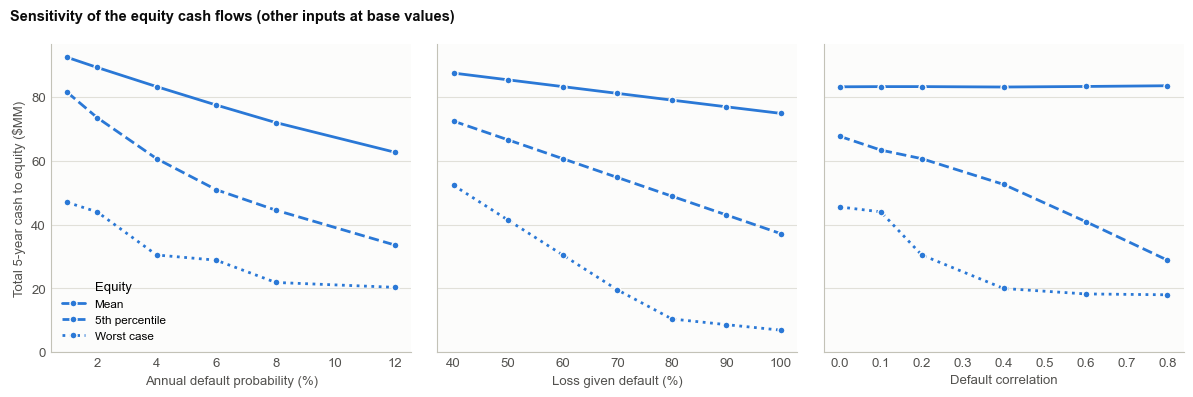

In [23]:
def plot_sensitivities(sens_pd, sens_lgd, sens_rho):
    """Mean, 5th percentile and worst case of total equity cash as each input is varied on its own."""
    panels = [
        (sens_pd, "Annual default probability (%)", 100),
        (sens_lgd, "Loss given default (%)", 100),
        (sens_rho, "Default correlation", 1),
    ]
    statistics = [("equity mean", "-", "Mean"), ("equity 5th pct", "--", "5th percentile"), ("equity min", ":", "Worst case")]
    fig, axes = plt.subplots(1, 3, figsize=(12, 4.0), sharey=True)
    for ax, (table, label, scale) in zip(axes, panels):
        x = table.index.values * scale
        for column, line_style, name in statistics:
            ax.plot(x, table[column], linestyle=line_style, color=COLORS["equity"], marker="o", markersize=5,
                    markeredgecolor=COLORS["surface"], markeredgewidth=1.0, label=name)
        ax.set_xlabel(label)
    axes[0].set_ylabel("Total 5-year cash to equity ($MM)")
    axes[0].set_ylim(bottom=0)
    axes[0].legend(title="Equity", loc="lower left")
    fig.suptitle("Sensitivity of the equity cash flows (other inputs at base values)", fontsize=10.5,
                 fontweight="bold", color=COLORS["ink"], x=0.01, ha="left")
    fig.tight_layout()
    return fig


plot_sensitivities(sens_pd, sens_lgd, sens_rho)
plt.show()

The classes only become risky when the LGD goes above the point where a fully defaulted pool can
no longer cover them. At maturity the worst case pool pays 101.5 x (1 - LGD) and A + B need 30.2,
so Class B is safe up to LGD = 1 - 30.2 / 101.5 = 70.2% and Class A up to 1 - 20.1 / 101.5 = 80.2%.
Above that it takes several defaults at once to cause a shortfall, which is where the default
probability and the correlation start to matter for the classes. The two tables below repeat the
PD and correlation runs with LGD set to 100% (nothing recovered).

In [24]:
stress = {**base, "lgd": 1.0}
stress_columns = ["avg defaults", "equity mean", "equity 5th pct", "P(A shortfall)", "P(B shortfall)", "B paid / due"]

# LGD = 100%, varying the annual default probability (correlation 0.20)
stress_pd = sensitivity(Z, stress, "pd", (0.04, 0.08, 0.12, 0.2))
stress_pd[stress_columns].round(4)

,avg defaults,equity mean,equity 5th pct,P(A shortfall),P(B shortfall),B paid / due
pd,,,,,,
0.04,1.821,74.8752,37.1425,0.001,0.006,0.9950
0.08,3.426,56.6929,11.7975,0.019,0.045,0.9623
0.12,4.730,42.4245,8.1975,0.056,0.118,0.9003
0.20,6.734,23.7548,4.6500,0.247,0.406,0.6542


In [25]:
# LGD = 100%, varying the correlation (annual default probability 4%)
stress_rho = sensitivity(Z, stress, "rho", (0.0, 0.2, 0.4, 0.6, 0.8))
stress_rho[stress_columns].round(4)

,avg defaults,equity mean,equity 5th pct,P(A shortfall),P(B shortfall),B paid / due
rho,,,,,,
0.0,1.833,74.7060,48.8000,0.000,0.000,1.0000
0.2,1.821,74.8752,37.1425,0.001,0.006,0.9950
0.4,1.844,75.0794,23.6925,0.016,0.029,0.9754
0.6,1.817,75.8664,12.0425,0.032,0.051,0.9560
0.8,1.782,77.4224,8.3500,0.069,0.089,0.9213


The last run changes the structure instead of the collateral: the Class B notional is increased
with everything else at base. In the worst case the pool pays 40.6 at maturity, Class A takes
20.1, and Class B is due 1.01 times its notional, so Class B stays fully covered up to
(40.6 - 20.1) / 1.01 = $20.3 MM. Beyond that its payment starts to depend on how many bonds default.

In [26]:
sens_b = sensitivity(Z, base, "b_notional", (10.0, 20.0, 30.0, 40.0, 50.0, 60.0))
sens_b[["equity mean", "equity 5th pct", "equity min", "P(A shortfall)", "P(B shortfall)", "B paid / due"]].round(4)

,equity mean,equity 5th pct,equity min,P(A shortfall),P(B shortfall),B paid / due
b_notional,,,,,,
10.0,83.2834,60.6855,30.48,0.0,0.000,1.0000
20.0,71.2834,48.6855,18.48,0.0,0.000,1.0000
30.0,59.2871,36.6855,10.19,0.0,0.001,0.9999
40.0,47.3537,24.6855,8.20,0.0,0.017,0.9985
50.0,35.6156,12.7800,6.30,0.0,0.033,0.9945
60.0,24.6959,10.0700,4.40,0.0,0.159,0.9804


## 10. Summary table for the write-up

In [27]:
summary = pd.DataFrame({
    "No-default amount ($MM)": stats["no-default amount"],
    "Mean ($MM)": stats["mean"],
    "Std error ($MM)": stats["std error"],
    "Std dev ($MM)": stats["std dev"],
    "5th pct ($MM)": stats["5th pct"],
    "Worst case ($MM)": stats["min"],
    "Mean / no-default amount": stats["mean / no-default amount"],
    "P(below no-default amount)": [(pool_total < pool_promised.sum() - 1e-9).mean(), (a_short > 1e-9).mean(),
                          (b_short > 1e-9).mean(), (eq_total < eq_promised - 1e-9).mean()],
})
summary.round(3)

,No-default amount ($MM),Mean ($MM),Std error ($MM),Std dev ($MM),5th pct ($MM),Worst case ($MM),Mean / no-default amount,P(below no-default amount)
Collateral pool,130.0,117.283,0.38,12.032,94.686,64.48,0.902,0.743
Class A,22.0,22.000,0.00,0.000,22.000,22.00,1.000,0.000
Class B,12.0,12.000,0.00,0.000,12.000,12.00,1.000,0.000
Equity (bank),96.0,83.283,0.38,12.032,60.686,30.48,0.868,0.743
